In [5]:
!pip install biolearn -q
from biolearn.data_library import DataLibrary

# Initialize the data library
library = DataLibrary()

# Load GSE41169 - blood tissue methylation dataset (95 samples, ages 18-65)
data_source = library.get("GSE41169")
data = data_source.load()

# Inspect metadata
print("First rows of metadata:")
print(data.metadata.head())

print("\nAge column statistics:")
print(data.metadata['age'].describe())

First rows of metadata:
            sex   age  disease
id                            
GSM1009660    1  32.0      2.0
GSM1009661    1  24.0      2.0
GSM1009662    1  65.0      2.0
GSM1009663    1  25.0      2.0
GSM1009664    0  32.0      2.0

Age column statistics:
count    95.000000
mean     31.568421
std      10.282864
min      18.000000
25%      24.500000
50%      29.000000
75%      36.000000
max      65.000000
Name: age, dtype: float64


In [6]:
# Verify methylation matrix dimensions (CpGs x samples)
print(type(data.dnam))
print(data.dnam.shape)

<class 'pandas.core.frame.DataFrame'>
(485577, 95)


In [7]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score, cross_val_predict
import matplotlib.pyplot as plt

# Transpose so rows = samples, columns = CpG features
X = data.dnam.T

# Define target variable
y = data.metadata['age']

# Align indices between methylation matrix and metadata
X, y = X.align(y, join='inner', axis=0)

# Dimensionality reduction: keep top 1000 features by variance
# Reduces ~485k CpGs to most informative sites
variances = X.var(axis=0)
top_features = variances.nlargest(1000).index
X = X[top_features]

# Fill missing values with column mean
X = X.fillna(X.mean())

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Age range: {y.min()} - {y.max()}")

# ElasticNet with optimized hyperparameters
model = ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=10000)
scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')

print(f"\nMAE per fold: {-scores.round(2)}")
print(f"Mean MAE: {-scores.mean():.2f} years")

X shape: (95, 1000)
y shape: (95,)
Age range: 18.0 - 65.0

MAE per fold: [9.94 6.84 8.88 8.4  6.22]
Mean MAE: 8.05 years


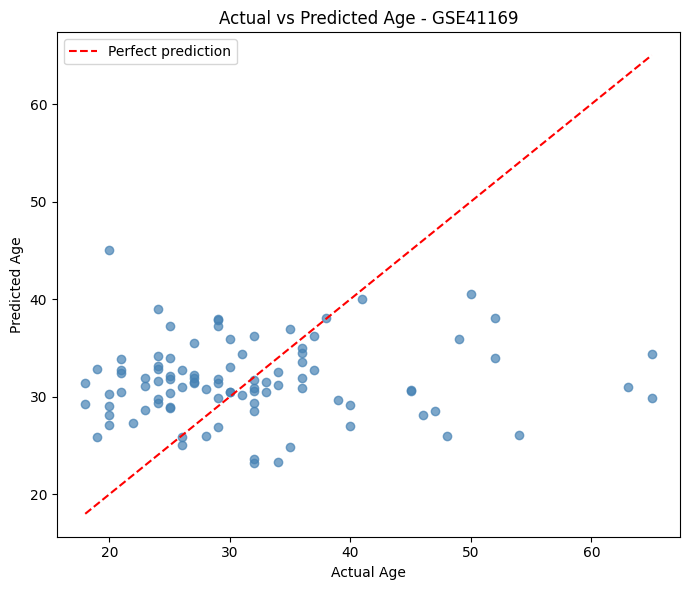

In [8]:
# Generate cross-validated predictions for visualization
y_pred_cv = cross_val_predict(
    ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=10000),
    X, y, cv=5
)

# Scatter plot: predicted vs actual age
plt.figure(figsize=(7,6))
plt.scatter(y, y_pred_cv, alpha=0.7, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')
plt.title('Actual vs Predicted Age - GSE41169')
plt.legend()
plt.tight_layout()
plt.show()